# Data Exploration: ERCOT Load and Renewable Output

This notebook scans raw ERCOT Excel files, profiles columns, builds a cleaned hourly dataset, and visualizes key trends.

In [16]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)

# Set up paths for raw data (original data directly from sources) and processed data (cleaned and transformed data ready for analysis)
ROOT = Path("C:/Renewable-PowerGrid-Risk")
RAW_DIR = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

all_files = sorted(RAW_DIR.glob('*.xlsx'))

load_files = [f for f in all_files if 'Native_Load' in f.name]
renewable_files = [f for f in all_files if 'WindSolar' in f.name]

print(load_files, renewable_files)

for f in all_files:
    print('-', f.name)

print(len(load_files),len(renewable_files))


[WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/Native_Load_2022.xlsx'), WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/Native_Load_2023.xlsx'), WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/Native_Load_2024.xlsx'), WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/Native_Load_2025.xlsx')] [WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/ERCOT_2023_Hourly_WindSolar_Output.xlsx'), WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/ERCOT_2024_Hourly_WindSolar_Output.xlsx'), WindowsPath('C:/Renewable-PowerGrid-Risk/data/raw/ERCOT_2025_Hourly_WindSolar_Output.xlsx')]
- ERCOT_2023_Hourly_WindSolar_Output.xlsx
- ERCOT_2024_Hourly_WindSolar_Output.xlsx
- ERCOT_2025_Hourly_WindSolar_Output.xlsx
- Native_Load_2022.xlsx
- Native_Load_2023.xlsx
- Native_Load_2024.xlsx
- Native_Load_2025.xlsx
4 3


In [17]:
load_frames = [pd.read_excel(f) for f in load_files]
renewable_frames = [pd.read_excel(f) for f in renewable_files]

load_df = pd.concat(load_frames, ignore_index=True) 
renewable_df = pd.concat(renewable_frames, ignore_index=True) 

print('Load rows:', len(load_df))
print('Renewable rows:', len(renewable_df))
display(load_df.head(3))
display(renewable_df.head(3))

Load rows: 35064
Renewable rows: 26304


,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
0,01/01/2022 01:00,12054.939199,1302.296674,4161.193625,757.843076,9676.300802,3172.878316,5908.031505,973.455700,38006.938896
1,01/01/2022 02:00,11793.290315,1259.355201,4147.907009,737.236591,9307.126712,3123.318608,5708.512022,959.775908,37036.522365
2,01/01/2022 03:00,11460.841252,1210.287905,4156.412366,725.610502,8920.424552,3003.396233,5463.522829,941.112359,35881.607998


,Time (Hour-Ending),Date,ERCOT.LOAD,ERCOT.WIND.GEN,"Total Wind Installed, MW","Wind Output, % of Load","Wind Output, % of Installed",Wind 1-hr MW change,Wind 1-hr % change
0,2023-01-01 01:00:00,2023-01-01,35829.306163,21753.284477,36858,60.713664,59.019167,NaN,NaN
1,2023-01-01 02:00:00,2023-01-01,35245.390234,21570.395694,36858,61.200615,58.522968,-182.888783,-0.840741
2,2023-01-01 03:00:00,2023-01-01,34599.761810,21036.504013,36858,60.799563,57.074459,-533.891682,-2.475113


,count,mean,min,25%,50%,75%,max,std
timestamp,34698,2024-01-07 07:11:07.646550272,2022-01-01 01:00:00,2023-01-12 17:15:00,2024-01-09 03:30:00,2025-01-04 13:45:00,2026-01-01 00:00:00,NaN
native_load_mw,33599.0,52130.461767,31796.35394,43929.664754,49436.403253,58395.042959,85464.116394,11105.75103
renewable_output_mw,26301.0,12721.776029,37.929258,6984.308713,12330.326026,18337.564826,28264.502331,6697.435097
hour,34698.0,11.621217,0.0,6.0,12.0,18.0,23.0,6.856785
month,34698.0,6.522998,1.0,4.0,7.0,10.0,12.0,3.44876
renewable_share,25202.0,0.250661,0.000782,0.125559,0.22751,0.359952,0.688718,0.149988


Saved merged dataset to: C:\Renewable-PowerGrid-Risk\data\processed\hourly_load_renewable_merged.csv


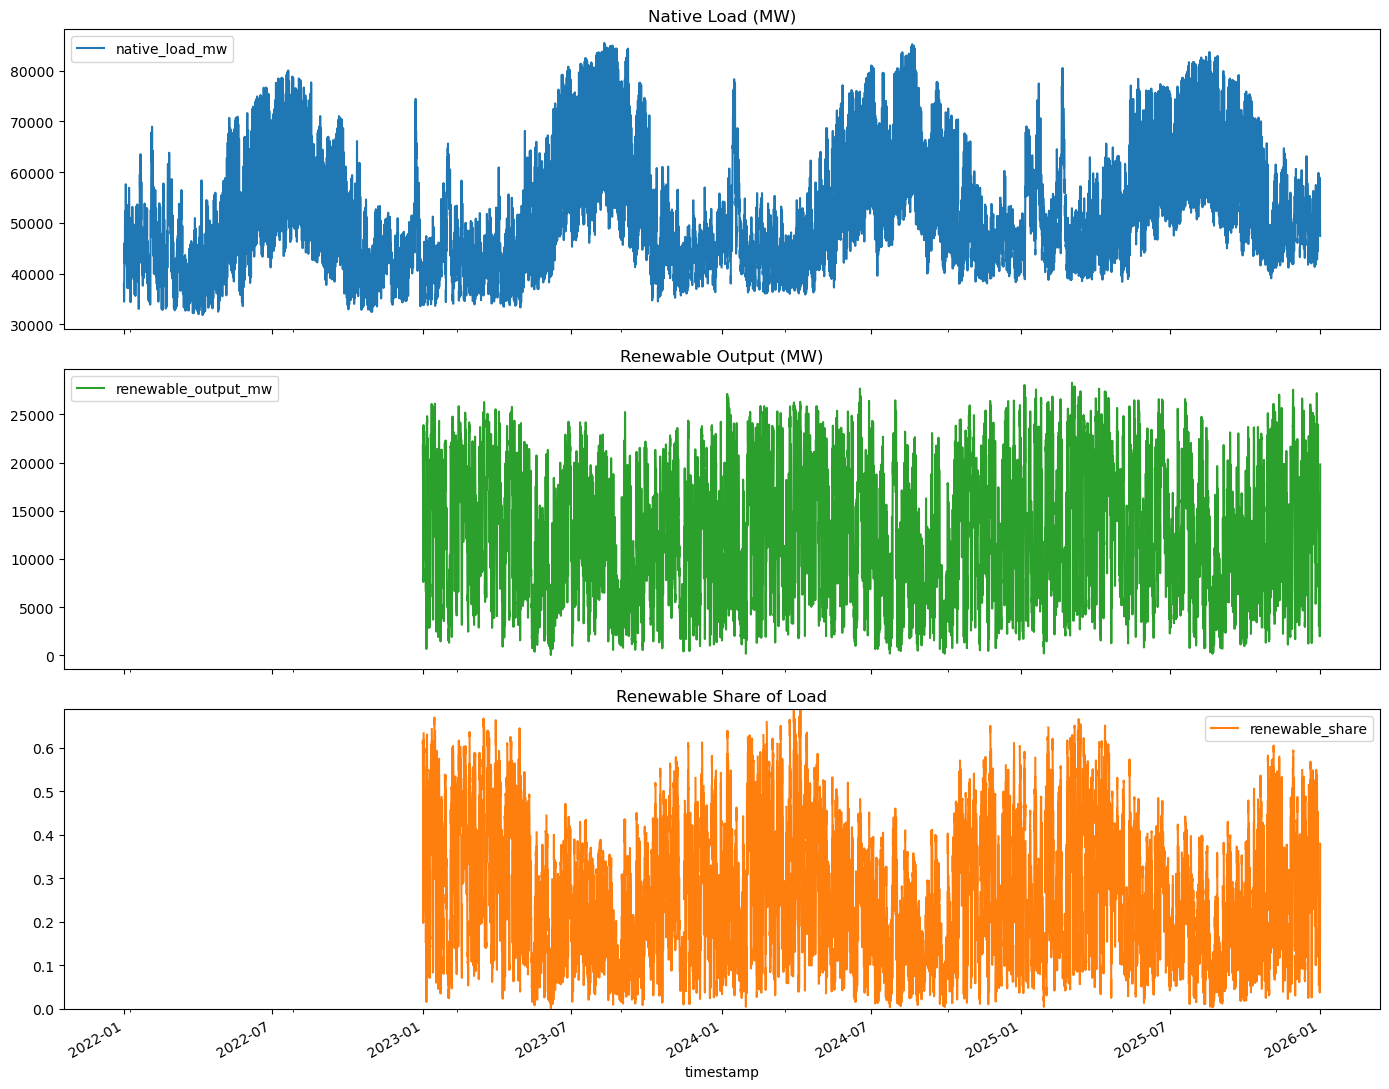

In [10]:
hourly = pd.merge(load_df[['timestamp', 'native_load_mw']], renewable_df[['timestamp', 'renewable_output_mw']], on='timestamp', how='outer')
hourly = hourly.sort_values('timestamp').drop_duplicates('timestamp')
hourly['hour'] = hourly['timestamp'].dt.hour
hourly['month'] = hourly['timestamp'].dt.month
hourly['renewable_share'] = hourly['renewable_output_mw'] / hourly['native_load_mw']

display(hourly.describe(include='all', datetime_is_numeric=True).T)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
hourly.plot(x='timestamp', y='native_load_mw', ax=axes[0], title='Native Load (MW)')
hourly.plot(x='timestamp', y='renewable_output_mw', ax=axes[1], title='Renewable Output (MW)', color='tab:green')
hourly.plot(x='timestamp', y='renewable_share', ax=axes[2], title='Renewable Share of Load', color='tab:orange')
axes[2].set_ylim(0, min(1.2, np.nanmax(hourly['renewable_share']) if len(hourly) else 1.0))
plt.tight_layout()

out_path = PROCESSED_DIR / 'hourly_load_renewable_merged.csv'
hourly.to_csv(out_path, index=False)
print('Saved merged dataset to:', out_path)

## Next Steps
1. Add anomaly labels (for example, top 1% load spikes and large residual changes).
2. Engineer lag and rolling-window features for model training in `src/`.
3. Compare seasonal patterns by year and month for grid-risk interpretation.